In [ ]:
"""
IMPROVED ROBUST Vehicle Insurance Fraud Detection Pipeline
Compact-MLP-based fraud pipeline for tabular insurance data

Main improvements over previous version:
- Replaces TabTransformer with compact MLP models
- True cross-validation
- Cleaner and safer preprocessing inside each fold
- Optional threshold tuning
- Better stability on smaller datasets
- Cleaner model comparison using fraud-focused ranking
- Reduced duplication in ROC generation and CV evaluation
"""

# =========================================================
# 0) Install
# =========================================================
import sys
import subprocess
import warnings
warnings.filterwarnings("ignore")

def _pip_install(pkgs):
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q"] + pkgs)

try:
    _pip_install(["imbalanced-learn", "xgboost"])
except Exception as e:
    print("Package install warning:", e)

# =========================================================
# 1) Imports
# =========================================================
import os
import gc
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

from sklearn.feature_selection import VarianceThreshold, SelectKBest, mutual_info_classif
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    precision_recall_fscore_support
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier, StackingClassifier
from sklearn.neighbors import KNeighborsClassifier

from imblearn.over_sampling import RandomOverSampler, SMOTE, ADASYN
from imblearn.under_sampling import RandomUnderSampler

from xgboost import XGBClassifier

import tensorflow as tf
from tensorflow.keras import layers, regularizers

# =========================================================
# 2) Reproducibility
# =========================================================
SEED = 42
np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)

# =========================================================
# 3) Config
# =========================================================
K = 10

# Data / pipeline choices
IMPUTATION_METHODS = ["knn"]                  # ["simple", "knn", "iterative"]
BASELINE_SAMPLING_METHODS = ["none"]         # ["none", "ros", "rus", "smote", "adasyn"]
DEEP_SAMPLING_METHODS = ["none"]             # deep models often prefer class weight over aggressive resampling
FEATURE_SELECTION = "mutual_info"            # "none" | "variance" | "mutual_info" | "rf_importance"
TOP_K_FEATURES = 20
VARIANCE_THRESHOLD = 0.001

RUN_DEEP_MODELS = True

# Threshold control
USE_THRESHOLD_TUNING = True
THRESHOLD_GRID = np.linspace(0.05, 0.95, 91)
THRESHOLD_METRIC = "f1"                      # "f1" | "recall" | "precision" | "balanced"
DEFAULT_THRESHOLD = 0.5

# Deep learning
DEEP_BATCH_SIZE = 16
DEEP_LR = 3e-4
DEEP_MIN_LR = 1e-6
EARLY_STOPPING_PATIENCE = 5
REDUCE_LR_PATIENCE = 2

DEEP_EPOCHS_CONVEX = 20
DEEP_EPOCHS_NONCONVEX = 20
DEEP_EPOCHS_STAGE1 = 5
DEEP_EPOCHS_STAGE2 = 15
DEEP_EPOCHS_STAGE3 = 10

# Weighted aggregate score
METRIC_WEIGHTS = {
    "auc": 0.30,
    "f1": 0.25,
    "recall": 0.15,
    "precision": 0.15,
    "specificity": 0.10,
    "accuracy": 0.05
}

# Ranking priority
METRIC_PRIORITY = [
    "fraud_recall",
    "auc",
    "fraud_f1",
    "weighted_average",
    "weighted_f1",
    "weighted_precision",
    "specificity",
    "accuracy"
]

# =========================================================
# 4) Load CSV
# =========================================================
try:
    from google.colab import files
    uploaded = files.upload()
    csv_name = list(uploaded.keys())[0]
except Exception:
    csv_name = "carclaims.csv"

df = pd.read_csv(csv_name)
# Shuffle rows
df = df.sample(frac=1, random_state=SEED).reset_index(drop=True)

print("Loaded:", csv_name, "shape:", df.shape)
print(df.head())


# =========================================================
# 5) Target detection + cleaning
# =========================================================
def pick_target_column(df):
    candidates = [
        "FraudFound_P",
        "FraudFound",
        "fraud_reported",
        "fraud",
        "is_fraud",
        "target",
        "Class",
        "label",
        "fraud_bool"
    ]
    cols_lower = {c.lower(): c for c in df.columns}
    for c in candidates:
        if c in df.columns:
            return c
        if c.lower() in cols_lower:
            return cols_lower[c.lower()]
    return df.columns[-1]

def refine_target_column(df, verbose=True):
    df = df.copy()
    target_col = pick_target_column(df)

    if verbose:
        print(f"\nTarget column detected: {target_col}")
        print("Original dtype:", df[target_col].dtype)
        print("Unique sample values:", df[target_col].dropna().astype(str).unique()[:10])

    s = df[target_col]

    if pd.api.types.is_numeric_dtype(s):
        uniq = sorted(pd.Series(s.dropna().unique()).tolist())
        if set(uniq).issubset({0, 1}):
            df[target_col] = s.astype(int)
        elif len(uniq) == 2:
            mapping = {uniq[0]: 0, uniq[1]: 1}
            df[target_col] = s.map(mapping).astype(int)
        else:
            thr = np.median(s.dropna())
            df[target_col] = (s > thr).astype(int)
    else:
        s_str = s.astype(str).str.strip().str.lower()
        map01 = {
            "y": 1, "yes": 1, "true": 1, "1": 1,
            "fraud": 1, "fraudulent": 1, "positive": 1,
            "n": 0, "no": 0, "false": 0, "0": 0,
            "not fraud": 0, "nonfraud": 0, "non-fraud": 0,
            "legit": 0, "legitimate": 0, "negative": 0
        }

        unique_vals = set(s_str.dropna().unique())
        if unique_vals.issubset(set(map01.keys())):
            df[target_col] = s_str.map(map01).astype(int)
        elif len(unique_vals) == 2:
            vals = sorted(unique_vals)
            mapping = {vals[0]: 0, vals[1]: 1}
            df[target_col] = s_str.map(mapping).astype(int)
            if verbose:
                print("Auto-mapped binary text labels:", mapping)
        else:
            enc = LabelEncoder()
            y_tmp = enc.fit_transform(s_str)
            if len(np.unique(y_tmp)) > 2:
                thr = np.median(y_tmp)
                y_tmp = (y_tmp > thr).astype(int)
            df[target_col] = y_tmp.astype(int)

    print("\nTarget distribution:")
    print(df[target_col].value_counts(dropna=False))
    print("\nTarget proportions:")
    print(df[target_col].value_counts(normalize=True).round(4))

    return df, target_col

df, target_col = refine_target_column(df)

# =========================================================
# 6) Prepare X, y
# =========================================================
X = df.drop(columns=[target_col]).copy()
y = df[target_col].values.astype(int)

categorical_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()
label_encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))
    label_encoders[col] = le

feature_names = X.columns.tolist()
X_np = X.values.astype(np.float32)
y_np = y.astype(int)

TOP_K_FEATURES = min(TOP_K_FEATURES, X_np.shape[1])

# =========================================================
# 7) Utility functions
# =========================================================
def specificity_score(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    if cm.shape != (2, 2):
        return 0.0
    tn, fp, fn, tp = cm.ravel()
    return tn / (tn + fp) if (tn + fp) > 0 else 0.0

def tune_threshold(y_true, y_prob, metric="f1", thresholds=None):
    if thresholds is None:
        thresholds = np.linspace(0.05, 0.95, 91)

    best_thr = 0.5
    best_score = -np.inf
    y_prob = np.asarray(y_prob).reshape(-1)

    for thr in thresholds:
        y_pred = (y_prob >= thr).astype(int)

        if metric == "f1":
            score = f1_score(y_true, y_pred, zero_division=0)
        elif metric == "recall":
            score = recall_score(y_true, y_pred, zero_division=0)
        elif metric == "precision":
            score = precision_score(y_true, y_pred, zero_division=0)
        elif metric == "balanced":
            score = 0.5 * (
                recall_score(y_true, y_pred, zero_division=0) +
                specificity_score(y_true, y_pred)
            )
        else:
            score = f1_score(y_true, y_pred, zero_division=0)

        if score > best_score:
            best_score = score
            best_thr = thr

    return float(best_thr), float(best_score)

def eval_binary_full(y_true, y_prob, thr=0.5):
    y_prob = np.asarray(y_prob, dtype=np.float64).reshape(-1)
    y_prob = np.nan_to_num(y_prob, nan=0.5, posinf=1.0, neginf=0.0)
    y_prob = np.clip(y_prob, 1e-7, 1.0 - 1e-7)
    y_pred = (y_prob >= thr).astype(int)

    cm = confusion_matrix(y_true, y_pred)
    if cm.shape == (2, 2):
        tn, fp, fn, tp = cm.ravel()
        specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    else:
        specificity = 0.0

    w_precision, w_recall, w_f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="weighted", zero_division=0
    )

    fraud_precision, fraud_recall, fraud_f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="binary", pos_label=1, zero_division=0
    )

    auc_value = 0.5
    try:
        auc_value = roc_auc_score(y_true, y_prob)
    except Exception:
        pass

    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "auc": auc_value,
        "specificity": specificity,
        "threshold": thr,
        "cm": cm,
        "weighted_precision": w_precision,
        "weighted_recall": w_recall,
        "weighted_f1": w_f1,
        "fraud_precision": fraud_precision,
        "fraud_recall": fraud_recall,
        "fraud_f1": fraud_f1,
    }

def compute_weighted_average(m):
    return (
        METRIC_WEIGHTS["auc"] * m["auc"] +
        METRIC_WEIGHTS["f1"] * m["weighted_f1"] +
        METRIC_WEIGHTS["recall"] * m["weighted_recall"] +
        METRIC_WEIGHTS["precision"] * m["weighted_precision"] +
        METRIC_WEIGHTS["specificity"] * m["specificity"] +
        METRIC_WEIGHTS["accuracy"] * m["accuracy"]
    )

def plot_roc_curves(y_true, curves, title="ROC Curves"):
    plt.figure(figsize=(8, 6))
    for label, prob in curves:
        prob = np.asarray(prob).reshape(-1)
        try:
            fpr, tpr, _ = roc_curve(y_true, prob)
            aucv = roc_auc_score(y_true, prob)
            plt.plot(fpr, tpr, label=f"{label} (AUC={aucv:.3f})")
        except Exception:
            continue
    plt.plot([0, 1], [0, 1], "--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

def build_imputer(method):
    if method == "simple":
        return SimpleImputer(strategy="median")
    elif method == "knn":
        return KNNImputer(n_neighbors=5)
    elif method == "iterative":
        return IterativeImputer(random_state=SEED)
    else:
        raise ValueError(f"Unknown imputation method: {method}")

def apply_sampling(method, Xtr, ytr, ratio=1.0):
    if method == "none":
        return Xtr, ytr
    elif method == "ros":
        sampler = RandomOverSampler(sampling_strategy=ratio, random_state=SEED)
    elif method == "rus":
        sampler = RandomUnderSampler(sampling_strategy=ratio, random_state=SEED)
    elif method == "smote":
        sampler = SMOTE(sampling_strategy=ratio, random_state=SEED)
    elif method == "adasyn":
        sampler = ADASYN(sampling_strategy=ratio, random_state=SEED)
    else:
        raise ValueError(f"Unknown sampling method: {method}")
    return sampler.fit_resample(Xtr, ytr)

def select_features(Xtr, ytr, Xva, method="mutual_info", top_k=20, variance_threshold=0.01):
    if method == "none":
        return Xtr, Xva, None

    if method == "variance":
        selector = VarianceThreshold(threshold=variance_threshold)
        Xtr_sel = selector.fit_transform(Xtr)
        Xva_sel = selector.transform(Xva)
        return Xtr_sel, Xva_sel, selector

    if method == "mutual_info":
        k = min(top_k, Xtr.shape[1])
        selector = SelectKBest(score_func=mutual_info_classif, k=k)
        Xtr_sel = selector.fit_transform(Xtr, ytr)
        Xva_sel = selector.transform(Xva)
        return Xtr_sel, Xva_sel, selector

    if method == "rf_importance":
        k = min(top_k, Xtr.shape[1])
        rf = RandomForestClassifier(
            n_estimators=300,
            random_state=SEED,
            n_jobs=-1,
            class_weight="balanced_subsample"
        )
        rf.fit(Xtr, ytr)
        idx = np.argsort(rf.feature_importances_)[::-1][:k]
        return Xtr[:, idx], Xva[:, idx], idx

    raise ValueError(f"Unknown feature selection method: {method}")

def get_selected_feature_names(selector, original_names):
    if selector is None:
        return original_names
    if hasattr(selector, "get_support"):
        mask = selector.get_support()
        return [name for name, keep in zip(original_names, mask) if keep]
    if isinstance(selector, np.ndarray):
        return [original_names[i] for i in selector]
    return original_names

def compute_class_weight_dict(y):
    y = np.asarray(y).astype(int).reshape(-1)
    n0 = np.sum(y == 0)
    n1 = np.sum(y == 1)
    if n0 == 0 or n1 == 0:
        return None
    return {
        0: (n0 + n1) / (2.0 * n0),
        1: (n0 + n1) / (2.0 * n1)
    }

def preprocess_fold(X_train, X_val, y_train):
    imputer = build_imputer(current_imputer_name)
    X_train_imp = imputer.fit_transform(X_train)
    X_val_imp = imputer.transform(X_val)

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_imp)
    X_val_scaled = scaler.transform(X_val_imp)

    X_train_fs, X_val_fs, selector = select_features(
        X_train_scaled, y_train, X_val_scaled,
        method=FEATURE_SELECTION,
        top_k=TOP_K_FEATURES,
        variance_threshold=VARIANCE_THRESHOLD
    )

    selected_names = get_selected_feature_names(selector, feature_names)
    return X_train_fs, X_val_fs, selector, selected_names

# =========================================================
# 8) Baseline model zoo
# =========================================================
def get_baseline_models():
    models = {
        "RandomForest": RandomForestClassifier(
            n_estimators=400,
            random_state=SEED,
            n_jobs=-1,
            class_weight="balanced_subsample",
            max_depth=None,
            min_samples_leaf=2
        ),
        # Uncomment if you want more baseline models
         "Bagging": BaggingClassifier(
             random_state=SEED,
             n_estimators=200
         ),
         "XGBoost": XGBClassifier(
             random_state=SEED,
             eval_metric="logloss",
             n_estimators=300,
             max_depth=5,
             learning_rate=0.05,
             subsample=0.9,
             colsample_bytree=0.9,
             reg_lambda=1.0
         )
    }

    stack_base = [
         ("rf", RandomForestClassifier(n_estimators=200, random_state=SEED, n_jobs=-1)),
         ("lr", LogisticRegression(max_iter=3000, random_state=SEED)),
         ("knn", KNeighborsClassifier())
     ]

    models["Stacking"] = StackingClassifier(
         estimators=stack_base,
         final_estimator=LogisticRegression(max_iter=3000, random_state=SEED),
         cv=5
     )

    return models

def get_model_probabilities(model, Xtr, ytr, Xva):
    model.fit(Xtr, ytr)

    if hasattr(model, "predict_proba"):
        return model.predict_proba(Xva)[:, 1]

    if hasattr(model, "decision_function"):
        scores = model.decision_function(Xva)
        scores = np.asarray(scores, dtype=float)
        smin, smax = scores.min(), scores.max()
        if smax - smin < 1e-12:
            return np.full_like(scores, 0.5, dtype=float)
        return (scores - smin) / (smax - smin)

    pred = model.predict(Xva)
    return pred.astype(float)

# =========================================================
# 9) Compact MLP-based deep models
# =========================================================
class ConvexFocalLoss(tf.keras.losses.Loss):
    def __init__(self, gamma=0.0, alpha_pos=0.5, alpha_neg=0.5, name="convex_focal_loss"):
        super().__init__(name=name)
        self.gamma = float(gamma)
        self.alpha_pos = float(alpha_pos)
        self.alpha_neg = float(alpha_neg)

    def call(self, y_true, y_pred_logits):
        y_true = tf.cast(y_true, tf.float32)
        p = tf.nn.sigmoid(y_pred_logits)
        p = tf.clip_by_value(p, 1e-7, 1.0 - 1e-7)

        loss = (
            - self.alpha_pos * y_true * tf.pow(1.0 - p, self.gamma) * tf.math.log(p)
            - self.alpha_neg * (1.0 - y_true) * tf.pow(p, self.gamma) * tf.math.log(1.0 - p)
        )
        return tf.reduce_mean(loss)

def dense_block(x, units, activation="relu", l2_reg=1e-3, dropout_rate=0.25, use_bn=True):
    x = layers.Dense(
        units,
        activation=activation,
        kernel_regularizer=regularizers.l2(l2_reg)
    )(x)
    if use_bn:
        x = layers.BatchNormalization()(x)
    x = layers.Dropout(dropout_rate)(x)
    return x

def build_compact_mlp_convex(input_dim):
    inp = layers.Input(shape=(input_dim,), name="tabular_input")

    x = layers.BatchNormalization()(inp)
    x = layers.GaussianNoise(0.01)(x)

    x = layers.Dense(
        256,
        activation="softplus",
        kernel_regularizer=regularizers.l2(1e-3)
    )(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.30)(x)

    x = layers.Dense(
        128,
        activation="softplus",
        kernel_regularizer=regularizers.l2(1e-3)
    )(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.20)(x)

    logits = layers.Dense(1, activation=None, name="logits")(x)
    return tf.keras.Model(inp, logits, name="compact_mlp_convex")

def build_compact_mlp_nonconvex(input_dim):
    inp = layers.Input(shape=(input_dim,), name="tabular_input")

    x = layers.BatchNormalization()(inp)
    x = layers.GaussianNoise(0.01)(x)

    x = dense_block(
        x,
        units=256,
        activation="swish",
        l2_reg=1e-3,
        dropout_rate=0.30,
        use_bn=True
    )

    x = dense_block(
        x,
        units=128,
        activation="swish",
        l2_reg=1e-3,
        dropout_rate=0.20,
        use_bn=True
    )

    x = dense_block(
        x,
        units=256,
        activation="swish",
        l2_reg=1e-3,
        dropout_rate=0.10,
        use_bn=True
    )

    prob = layers.Dense(1, activation="sigmoid", name="prob")(x)
    return tf.keras.Model(inp, prob, name="compact_mlp_nonconvex")

def transfer_weights_best_effort(src_model, dst_model):
    src_weights = {w.name: w.numpy() for w in src_model.weights}
    for w in dst_model.weights:
        if w.name in src_weights and src_weights[w.name].shape == tuple(w.shape):
            w.assign(src_weights[w.name])

def get_callbacks():
    return [
        tf.keras.callbacks.EarlyStopping(
            monitor="val_auc",
            mode="max",
            patience=EARLY_STOPPING_PATIENCE,
            restore_best_weights=True,
            verbose=0
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor="val_auc",
            mode="max",
            factor=0.5,
            patience=REDUCE_LR_PATIENCE,
            min_lr=DEEP_MIN_LR,
            verbose=0
        )
    ]

def run_schedule(schedule, Xtr, ytr, Xva, yva, class_weight=None, batch_size=32, lr=1e-3, verbose=0):
    input_dim = Xtr.shape[1]
    model = None

    for st in schedule:
        if st["builder"] == "convex":
            new_model = build_compact_mlp_convex(input_dim)
        else:
            new_model = build_compact_mlp_nonconvex(input_dim)

        if model is not None:
            transfer_weights_best_effort(model, new_model)

        model = new_model
        optimizer = tf.keras.optimizers.Adam(learning_rate=lr, clipnorm=5.0)

        model.compile(
            optimizer=optimizer,
            loss=st["loss"],
            metrics=[
                tf.keras.metrics.BinaryAccuracy(name="acc"),
                tf.keras.metrics.AUC(name="auc")
            ]
        )

        model.fit(
            Xtr, ytr,
            validation_data=(Xva, yva),
            epochs=st["epochs"],
            batch_size=batch_size,
            verbose=verbose,
            class_weight=class_weight,
            callbacks=get_callbacks()
        )

    if schedule[-1]["builder"] == "convex":
        logits = model.predict(Xva, verbose=0).reshape(-1)
        prob = tf.nn.sigmoid(logits).numpy()
    else:
        prob = model.predict(Xva, verbose=0).reshape(-1)

    prob = np.nan_to_num(prob, nan=0.5, posinf=1.0, neginf=0.0)
    prob = np.clip(prob, 1e-7, 1.0 - 1e-7)
    return prob

def make_adaptive_focal_schedules(y_train):
    class_weight = compute_class_weight_dict(y_train)

    convex_loss = ConvexFocalLoss(
        gamma=0.0,
        alpha_pos=0.5, #0.25
        alpha_neg=0.5
    )

    nonconvex_focal = tf.keras.losses.BinaryFocalCrossentropy(
        apply_class_balancing=True,
        alpha=0.55,
        gamma=0.5,
        from_logits=False
    )

    hybrid_focal = tf.keras.losses.BinaryFocalCrossentropy(
        apply_class_balancing=True,
        alpha=0.55,
        gamma=0.5,
        from_logits=False
    )

    schedule_convex = [
        {"stage": "ConvexWarmStart", "builder": "convex", "loss": convex_loss, "epochs": DEEP_EPOCHS_CONVEX},
    ]

    schedule_nonconvex = [
        {"stage": "NonConvexFocal", "builder": "nonconvex", "loss": nonconvex_focal, "epochs": DEEP_EPOCHS_NONCONVEX},
    ]

    schedule_multistage = [
        {"stage": "Stage1_ConvexWarmStart", "builder": "convex", "loss": convex_loss, "epochs": DEEP_EPOCHS_STAGE1},
        {"stage": "Stage2_NonConvexFocal", "builder": "nonconvex", "loss": nonconvex_focal, "epochs": DEEP_EPOCHS_STAGE2},
        #{"stage": "Stage3_HybridFocal", "builder": "nonconvex", "loss": hybrid_focal, "epochs": DEEP_EPOCHS_STAGE3},
    ]

    return class_weight, schedule_convex, schedule_nonconvex, schedule_multistage

# =========================================================
# 10) OOF prediction runner
# =========================================================
def generate_oof_predictions(imputer_name, baseline_sampler_name, deep_sampler_name):
    global current_imputer_name
    current_imputer_name = imputer_name

    skf = StratifiedKFold(n_splits=K, shuffle=True, random_state=SEED)
    baseline_models = get_baseline_models()

    model_oof = {name: np.zeros(len(y_np), dtype=float) for name in baseline_models.keys()}
    feature_freq = {}

    if RUN_DEEP_MODELS:
        model_oof["ConvexFocal_CompactMLP"] = np.zeros(len(y_np), dtype=float)
        model_oof["NonConvexFocal_CompactMLP"] = np.zeros(len(y_np), dtype=float)
        model_oof["MultistageFocal_CompactMLP"] = np.zeros(len(y_np), dtype=float)

    for fold, (tr_idx, va_idx) in enumerate(skf.split(X_np, y_np), start=1):
        print(f"  Fold {fold}/{K}")

        X_train, X_val = X_np[tr_idx], X_np[va_idx]
        y_train, y_val = y_np[tr_idx], y_np[va_idx]

        X_train_fs, X_val_fs, selector, selected_names = preprocess_fold(X_train, X_val, y_train)

        for name in selected_names:
            feature_freq[name] = feature_freq.get(name, 0) + 1

        # baseline branch
        Xtr_base, ytr_base = apply_sampling(baseline_sampler_name, X_train_fs, y_train, ratio=1.0)

        for model_name, model in baseline_models.items():
            probs = get_model_probabilities(model, Xtr_base, ytr_base, X_val_fs)
            model_oof[model_name][va_idx] = probs

        # deep branch
        if RUN_DEEP_MODELS:
            Xtr_deep, ytr_deep = apply_sampling(deep_sampler_name, X_train_fs, y_train, ratio=0.8)

            Xtr_tf = Xtr_deep.astype(np.float32)
            Xva_tf = X_val_fs.astype(np.float32)
            ytr_tf = ytr_deep.astype(np.float32).reshape(-1, 1)
            yva_tf = y_val.astype(np.float32).reshape(-1, 1)

            class_weight, schedule_convex, schedule_nonconvex, schedule_multistage = make_adaptive_focal_schedules(ytr_deep)

            model_oof["ConvexFocal_CompactMLP"][va_idx] = run_schedule(
                schedule_convex,
                Xtr_tf, ytr_tf, Xva_tf, yva_tf,
                class_weight=class_weight,
                batch_size=DEEP_BATCH_SIZE,
                lr=DEEP_LR,
                verbose=0
            )

            model_oof["NonConvexFocal_CompactMLP"][va_idx] = run_schedule(
                schedule_nonconvex,
                Xtr_tf, ytr_tf, Xva_tf, yva_tf,
                class_weight=class_weight,
                batch_size=DEEP_BATCH_SIZE,
                lr=DEEP_LR,
                verbose=0
            )

            p1 = run_schedule(
                schedule_multistage,
                Xtr_tf, ytr_tf, Xva_tf, yva_tf,
                class_weight=class_weight,
                batch_size=DEEP_BATCH_SIZE,
                lr=DEEP_LR,
                verbose=0
            )

            p2 = run_schedule(
                schedule_multistage,
                Xtr_tf, ytr_tf, Xva_tf, yva_tf,
                class_weight=class_weight,
                batch_size=DEEP_BATCH_SIZE,
                lr=DEEP_LR * 0.8,
                verbose=0
            )

            model_oof["MultistageFocal_CompactMLP"][va_idx] = 0.5 * (p1 + p2)

            tf.keras.backend.clear_session()
            gc.collect()

    return model_oof, feature_freq

# =========================================================
# 11) Cross-validated evaluation
# =========================================================
all_summary_rows = []
best_config = None
best_score = None
overall_feature_freq = {}

for imputer_name in IMPUTATION_METHODS:
    for baseline_sampler_name in BASELINE_SAMPLING_METHODS:
        for deep_sampler_name in DEEP_SAMPLING_METHODS:

            print(f"\n=== Config: imputer={imputer_name}, baseline_sampler={baseline_sampler_name}, deep_sampler={deep_sampler_name}, fs={FEATURE_SELECTION} ===")

            model_oof, feature_freq = generate_oof_predictions(
                imputer_name=imputer_name,
                baseline_sampler_name=baseline_sampler_name,
                deep_sampler_name=deep_sampler_name
            )

            for k, v in feature_freq.items():
                overall_feature_freq[k] = overall_feature_freq.get(k, 0) + v

            for model_name, probs in model_oof.items():
                if USE_THRESHOLD_TUNING:
                    best_thr, _ = tune_threshold(
                        y_np,
                        probs,
                        metric=THRESHOLD_METRIC,
                        thresholds=THRESHOLD_GRID
                    )
                else:
                    best_thr = DEFAULT_THRESHOLD

                #m = eval_binary_full(y_np, probs, thr=best_thr)
                m = eval_binary_full(y_np, probs)
                weighted_average = compute_weighted_average(m)

                row = {
                    "imputer": imputer_name,
                    "baseline_sampler": baseline_sampler_name,
                    "deep_sampler": deep_sampler_name,
                    "feature_selection": FEATURE_SELECTION,
                    "model": model_name,

                    "accuracy": m["accuracy"],
                    "auc": m["auc"],
                    "specificity": m["specificity"],
                    "threshold": m["threshold"],

                    "weighted_precision": m["weighted_precision"],
                    "weighted_recall": m["weighted_recall"],
                    "weighted_f1": m["weighted_f1"],
                    "weighted_average": weighted_average,

                    "fraud_precision": m["fraud_precision"],
                    "fraud_recall": m["fraud_recall"],
                    "fraud_f1": m["fraud_f1"],
                }

                all_summary_rows.append(row)

                current_score = (
                    m["fraud_recall"],
                    m["auc"],
                    m["fraud_f1"],
                    weighted_average,
                    m["weighted_f1"],
                    m["weighted_precision"],
                    m["specificity"],
                    m["accuracy"]
                )

                if best_config is None or current_score > best_score:
                    best_score = current_score
                    best_config = row.copy()

# =========================================================
# 12) Results summary
# =========================================================
summary = pd.DataFrame(all_summary_rows).sort_values(
    METRIC_PRIORITY,
    ascending=[False] * len(METRIC_PRIORITY)
)

print("\nTop results:")
print(summary.head(20).to_string(index=False))

print("\nBest configuration:")
print(best_config)

# =========================================================
# 13) Best-per-model table
# =========================================================
best_per_model = (
    summary.sort_values(
        ["model"] + METRIC_PRIORITY,
        ascending=[True] + [False] * len(METRIC_PRIORITY)
    )
    .groupby("model", as_index=False)
    .first()
    .sort_values(METRIC_PRIORITY, ascending=[False] * len(METRIC_PRIORITY))
)

print("\nBest row per model:")
print(best_per_model.to_string(index=False))

# =========================================================
# 14) ROC curves for top models
# =========================================================
top_models = best_per_model["model"].head(5).tolist()
print("\nTop models:", top_models)

best_imp = best_config["imputer"]
best_baseline_sampler = best_config["baseline_sampler"]
best_deep_sampler = best_config["deep_sampler"]

best_model_oof, _ = generate_oof_predictions(
    imputer_name=best_imp,
    baseline_sampler_name=best_baseline_sampler,
    deep_sampler_name=best_deep_sampler
)

curves = [(mdl, best_model_oof[mdl]) for mdl in top_models]
plot_roc_curves(y_np, curves, title="Top Model ROC Curves")

# =========================================================
# 15) Feature frequency report
# =========================================================
feature_freq_df = pd.DataFrame(
    [{"feature": k, "count": v} for k, v in overall_feature_freq.items()]
).sort_values("count", ascending=False)

print("\nMost frequently selected features:")
print(feature_freq_df.head(20).to_string(index=False))

# =========================================================
# 16) Export
# =========================================================
summary.to_csv("compact_mlp_fraud_pipeline_all_results.csv", index=False)
best_per_model.to_csv("compact_mlp_fraud_pipeline_best_per_model.csv", index=False)
feature_freq_df.to_csv("compact_mlp_fraud_pipeline_feature_frequency.csv", index=False)

print("\nSaved:")
print(" - compact_mlp_fraud_pipeline_all_results.csv")
print(" - compact_mlp_fraud_pipeline_best_per_model.csv")
print(" - compact_mlp_fraud_pipeline_feature_frequency.csv")

KeyboardInterrupt: 


Target column detected: fraud reported
Original dtype: object
Unique sample values: ['N' 'Y']

Target distribution:
fraud reported
0    9043
1    2959
Name: count, dtype: int64

Target proportions:
fraud reported
0    0.7535
1    0.2465
Name: proportion, dtype: float64

=== Config: imputer=knn, baseline_sampler=none, deep_sampler=none, fs=mutual_info ===
  Fold 1/10
  Fold 2/10
  Fold 3/10
  Fold 4/10
  Fold 5/10
  Fold 6/10
  Fold 7/10
  Fold 8/10
  Fold 9/10
  Fold 10/10

Top results:
imputer baseline_sampler deep_sampler feature_selection                               model  accuracy      auc  specificity  threshold  weighted_precision  weighted_recall  weighted_f1  weighted_average  fraud_precision  fraud_recall  fraud_f1
    knn             none         none       mutual_info  LogisticRegression_Focal_NonConvex  0.391685 0.638400     0.197501        0.5            0.805994         0.391685     0.356988          0.499753         0.286571      0.985130  0.443988
    knn            

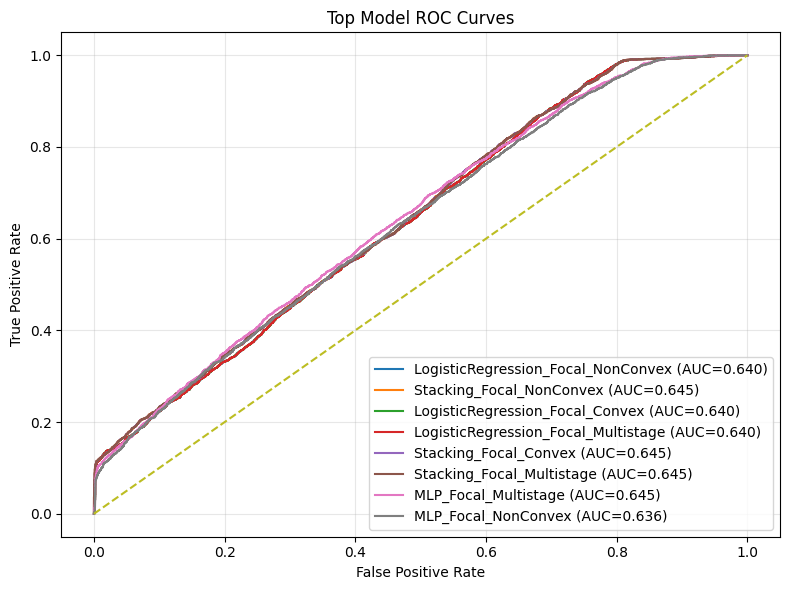


Most frequently selected features:
           feature  count
     annual_income     10
      form defects     10
 policy deductible     10
     vehicle_price     10
         liab_prct      9
   witness_present      9
         days open      9
    annual premium      9
     vehicle_color      9
      claim_number      9
    age_of_vehicle      9
    address_change      9
      injury_claim      8
  vehicle_category      8
       total_claim      8
            gender      7
          zip_code      7
           channel      6
past_num_of_claims      6
    high_education      6

Saved:
 - fraud_pipeline_all_results_4_variants_per_model.csv
 - fraud_pipeline_best_per_model_4_variants_per_model.csv
 - fraud_pipeline_family_variant_deltas.csv
 - fraud_pipeline_feature_frequency.csv


In [2]:
"""
UPDATED ROBUST Vehicle Insurance Fraud Detection Pipeline
Standard + 3 focal variants for each model family:
- XGBoost
- RandomForest
- Bagging
- Logistic Regression
- LightGBM
- Stacking
- MLP

Focal variants:
1) Convex focal        : gamma = 0
2) Nonconvex focal     : gamma > 0
3) Multistage focal    : convex focal -> nonconvex focal

Main update in this version
---------------------------
1. Different alpha/gamma are assigned to each baseline family.
2. Stacking also uses its own alpha/gamma.
3. Deep MLP focal settings are also separated.
4. Threshold tuning now correctly uses best_thr inside eval_binary_full.
"""

# =========================================================
# 0) Install
# =========================================================
import sys
import subprocess
import warnings
warnings.filterwarnings("ignore")

def _pip_install(pkgs):
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q"] + pkgs)

try:
    _pip_install(["imbalanced-learn", "xgboost", "lightgbm"])
except Exception as e:
    print("Package install warning:", e)

# =========================================================
# 1) Imports
# =========================================================
import os
import gc
import random
import inspect
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import BaseEstimator, ClassifierMixin, clone
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

from sklearn.feature_selection import VarianceThreshold, SelectKBest, mutual_info_classif
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    precision_recall_fscore_support
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

from imblearn.over_sampling import RandomOverSampler, SMOTE, ADASYN
from imblearn.under_sampling import RandomUnderSampler

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

import tensorflow as tf
from tensorflow.keras import layers, regularizers

# =========================================================
# 2) Reproducibility
# =========================================================
SEED = 42
np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)

# =========================================================
# 3) Config
# =========================================================
K = 10

# Data / pipeline choices
IMPUTATION_METHODS = ["knn"]                  # ["simple", "knn", "iterative"]
BASELINE_SAMPLING_METHODS = ["none"]         # ["none", "ros", "rus", "smote", "adasyn"]
DEEP_SAMPLING_METHODS = ["none"]             # deep models often prefer class weight over aggressive resampling
FEATURE_SELECTION = "mutual_info"            # "none" | "variance" | "mutual_info" | "rf_importance"
TOP_K_FEATURES = 20
VARIANCE_THRESHOLD = 0.01
RUN_DEEP_MODELS = True

# Use full data by default
DATA_FRACTION = 1.0

# Threshold control
USE_THRESHOLD_TUNING = True
THRESHOLD_GRID = np.linspace(0.05, 0.95, 91)
THRESHOLD_METRIC = "f1"                      # "f1" | "recall" | "precision" | "balanced"
DEFAULT_THRESHOLD = 0.5

# ---------------------------------------------------------
# Global default focal settings fallback
# ---------------------------------------------------------
FOCAL_ALPHA = 0.65,
FOCAL_GAMMA_CONVEX = 0.0
FOCAL_GAMMA_NONCONVEX = 2

# ---------------------------------------------------------
# Per-family focal settings for classical models + stacking
# ---------------------------------------------------------
FOCAL_CONFIG = {
    "RandomForest": {
        "alpha":  0.65,
        "gamma_convex": 0.0,
        "gamma_nonconvex": 0.05
    },
    "Bagging": {
        "alpha": 0.65,
        "gamma_convex": 0.0,
        "gamma_nonconvex": 0.03
    },
    "LogisticRegression": {
        "alpha": 0.65,
        "gamma_convex": 0.0,
        "gamma_nonconvex": 0.05
    },
    "XGBoost": {
        "alpha": 0.65,
        "gamma_convex": 0.0,
        "gamma_nonconvex": 0.15
    },
    "LightGBM": {
        "alpha":  0.65,
        "gamma_convex": 0.0,
        "gamma_nonconvex": 1
    },
    "Stacking": {
        "alpha": 0.65,
        "gamma_convex": 0.0,
        "gamma_nonconvex": 0.15
    },
}

# ---------------------------------------------------------
# Per-family focal settings for deep MLP
# ---------------------------------------------------------
DEEP_FOCAL_CONFIG = {
    "MLP": {
        "alpha_pos": 0.65,
        "alpha_neg": 0.25,
        "gamma_convex": 0.0,
        "gamma_nonconvex": 2.0
    }
}

# Deep learning
DEEP_BATCH_SIZE = 32
DEEP_LR = 3e-4
DEEP_MIN_LR = 1e-6
EARLY_STOPPING_PATIENCE = 5
REDUCE_LR_PATIENCE = 2

DEEP_EPOCHS_STANDARD = 20
DEEP_EPOCHS_CONVEX = 20
DEEP_EPOCHS_NONCONVEX = 20
DEEP_EPOCHS_STAGE1 = 5
DEEP_EPOCHS_STAGE2 = 15

# Weighted aggregate score
METRIC_WEIGHTS = {
    "auc": 0.30,
    "f1": 0.25,
    "recall": 0.15,
    "precision": 0.15,
    "specificity": 0.10,
    "accuracy": 0.05
}

# Ranking priority
METRIC_PRIORITY = [
    "fraud_recall",
    "auc",
    "fraud_f1",
    "weighted_average",
    "weighted_f1",
    "weighted_precision",
    "specificity",
    "accuracy"
]

# =========================================================
# 4) Load CSV
# =========================================================
#try:
 #   from google.colab import files
#    uploaded = files.upload()
#    csv_name = list(uploaded.keys())[0]
#except Exception:
#csv_name = "Dataset-2.csv

df = pd.read_csv("insurance_fraud_data.csv")

#if 0 < DATA_FRACTION < 1.0:
df = df.sample(frac=1, random_state=SEED).reset_index(drop=True)

#print("Loaded:", csv_name, "shape:", df.shape)
#print(df.head())

# =========================================================
# 5) Target detection + cleaning
# =========================================================
def pick_target_column(df):
    candidates = [
        "FraudFound_P",
        "FraudFound",
        "fraud_reported",
        "fraud",
        "is_fraud",
        "target",
        "Class",
        "label",
        "fraud_bool"
    ]
    cols_lower = {c.lower(): c for c in df.columns}
    for c in candidates:
        if c in df.columns:
            return c
        if c.lower() in cols_lower:
            return cols_lower[c.lower()]
    return df.columns[-1]

def refine_target_column(df, verbose=True):
    df = df.copy()
    target_col = pick_target_column(df)

    if verbose:
        print(f"\nTarget column detected: {target_col}")
        print("Original dtype:", df[target_col].dtype)
        print("Unique sample values:", df[target_col].dropna().astype(str).unique()[:10])

    s = df[target_col]

    if pd.api.types.is_numeric_dtype(s):
        uniq = sorted(pd.Series(s.dropna().unique()).tolist())
        if set(uniq).issubset({0, 1}):
            df[target_col] = s.astype(int)
        elif len(uniq) == 2:
            mapping = {uniq[0]: 0, uniq[1]: 1}
            df[target_col] = s.map(mapping).astype(int)
        else:
            thr = np.median(s.dropna())
            df[target_col] = (s > thr).astype(int)
    else:
        s_str = s.astype(str).str.strip().str.lower()
        map01 = {
            "y": 1, "yes": 1, "true": 1, "1": 1,
            "fraud": 1, "fraudulent": 1, "positive": 1,
            "n": 0, "no": 0, "false": 0, "0": 0,
            "not fraud": 0, "nonfraud": 0, "non-fraud": 0,
            "legit": 0, "legitimate": 0, "negative": 0
        }

        unique_vals = set(s_str.dropna().unique())
        if unique_vals.issubset(set(map01.keys())):
            df[target_col] = s_str.map(map01).astype(int)
        elif len(unique_vals) == 2:
            vals = sorted(unique_vals)
            mapping = {vals[0]: 0, vals[1]: 1}
            df[target_col] = s_str.map(mapping).astype(int)
            if verbose:
                print("Auto-mapped binary text labels:", mapping)
        else:
            enc = LabelEncoder()
            y_tmp = enc.fit_transform(s_str)
            if len(np.unique(y_tmp)) > 2:
                thr = np.median(y_tmp)
                y_tmp = (y_tmp > thr).astype(int)
            df[target_col] = y_tmp.astype(int)

    print("\nTarget distribution:")
    print(df[target_col].value_counts(dropna=False))
    print("\nTarget proportions:")
    print(df[target_col].value_counts(normalize=True).round(4))

    return df, target_col

df, target_col = refine_target_column(df)

# =========================================================
# 6) Prepare X, y
# =========================================================
X = df.drop(columns=[target_col]).copy()
y = df[target_col].values.astype(int)

categorical_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()
label_encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))
    label_encoders[col] = le

feature_names = X.columns.tolist()
X_np = X.values.astype(np.float32)
y_np = y.astype(int)

TOP_K_FEATURES = min(TOP_K_FEATURES, X_np.shape[1])

# =========================================================
# 7) Utility functions
# =========================================================
def specificity_score(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    if cm.shape != (2, 2):
        return 0.0
    tn, fp, fn, tp = cm.ravel()
    return tn / (tn + fp) if (tn + fp) > 0 else 0.0

def tune_threshold(y_true, y_prob, metric="f1", thresholds=None):
    if thresholds is None:
        thresholds = np.linspace(0.05, 0.95, 91)

    best_thr = 0.5
    best_score = -np.inf
    y_prob = np.asarray(y_prob).reshape(-1)

    for thr in thresholds:
        y_pred = (y_prob >= thr).astype(int)

        if metric == "f1":
            score = f1_score(y_true, y_pred, zero_division=0)
        elif metric == "recall":
            score = recall_score(y_true, y_pred, zero_division=0)
        elif metric == "precision":
            score = precision_score(y_true, y_pred, zero_division=0)
        elif metric == "balanced":
            score = 0.5 * (
                recall_score(y_true, y_pred, zero_division=0) +
                specificity_score(y_true, y_pred)
            )
        else:
            score = f1_score(y_true, y_pred, zero_division=0)

        if score > best_score:
            best_score = score
            best_thr = thr

    return float(best_thr), float(best_score)

def eval_binary_full(y_true, y_prob, thr=0.5):
    y_prob = np.asarray(y_prob, dtype=np.float64).reshape(-1)
    y_prob = np.nan_to_num(y_prob, nan=0.5, posinf=1.0, neginf=0.0)
    y_prob = np.clip(y_prob, 1e-7, 1.0 - 1e-7)
    y_pred = (y_prob >= thr).astype(int)

    cm = confusion_matrix(y_true, y_pred)
    if cm.shape == (2, 2):
        tn, fp, fn, tp = cm.ravel()
        specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    else:
        specificity = 0.0

    w_precision, w_recall, w_f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="weighted", zero_division=0
    )

    fraud_precision, fraud_recall, fraud_f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="binary", pos_label=1, zero_division=0
    )

    auc_value = 0.5
    try:
        auc_value = roc_auc_score(y_true, y_prob)
    except Exception:
        pass

    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "auc": auc_value,
        "specificity": specificity,
        "threshold": thr,
        "cm": cm,
        "weighted_precision": w_precision,
        "weighted_recall": w_recall,
        "weighted_f1": w_f1,
        "fraud_precision": fraud_precision,
        "fraud_recall": fraud_recall,
        "fraud_f1": fraud_f1,
    }

def compute_weighted_average(m):
    return (
        METRIC_WEIGHTS["auc"] * m["auc"] +
        METRIC_WEIGHTS["f1"] * m["weighted_f1"] +
        METRIC_WEIGHTS["recall"] * m["weighted_recall"] +
        METRIC_WEIGHTS["precision"] * m["weighted_precision"] +
        METRIC_WEIGHTS["specificity"] * m["specificity"] +
        METRIC_WEIGHTS["accuracy"] * m["accuracy"]
    )

def plot_roc_curves(y_true, curves, title="ROC Curves"):
    plt.figure(figsize=(8, 6))
    for label, prob in curves:
        prob = np.asarray(prob).reshape(-1)
        try:
            fpr, tpr, _ = roc_curve(y_true, prob)
            aucv = roc_auc_score(y_true, prob)
            plt.plot(fpr, tpr, label=f"{label} (AUC={aucv:.3f})")
        except Exception:
            continue
    plt.plot([0, 1], [0, 1], "--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

def build_imputer(method):
    if method == "simple":
        return SimpleImputer(strategy="median")
    elif method == "knn":
        return KNNImputer(n_neighbors=5)
    elif method == "iterative":
        return IterativeImputer(random_state=SEED)
    else:
        raise ValueError(f"Unknown imputation method: {method}")

def apply_sampling(method, Xtr, ytr, ratio=1.0):
    if method == "none":
        return Xtr, ytr
    elif method == "ros":
        sampler = RandomOverSampler(sampling_strategy=ratio, random_state=SEED)
    elif method == "rus":
        sampler = RandomUnderSampler(sampling_strategy=ratio, random_state=SEED)
    elif method == "smote":
        sampler = SMOTE(sampling_strategy=ratio, random_state=SEED)
    elif method == "adasyn":
        sampler = ADASYN(sampling_strategy=ratio, random_state=SEED)
    else:
        raise ValueError(f"Unknown sampling method: {method}")
    return sampler.fit_resample(Xtr, ytr)

def select_features(Xtr, ytr, Xva, method="mutual_info", top_k=20, variance_threshold=0.01):
    if method == "none":
        return Xtr, Xva, None

    if method == "variance":
        selector = VarianceThreshold(threshold=variance_threshold)
        Xtr_sel = selector.fit_transform(Xtr)
        Xva_sel = selector.transform(Xva)
        return Xtr_sel, Xva_sel, selector

    if method == "mutual_info":
        k = min(top_k, Xtr.shape[1])
        selector = SelectKBest(score_func=mutual_info_classif, k=k)
        Xtr_sel = selector.fit_transform(Xtr, ytr)
        Xva_sel = selector.transform(Xva)
        return Xtr_sel, Xva_sel, selector

    if method == "rf_importance":
        k = min(top_k, Xtr.shape[1])
        rf = RandomForestClassifier(
            n_estimators=300,
            random_state=SEED,
            n_jobs=-1,
            class_weight="balanced_subsample"
        )
        rf.fit(Xtr, ytr)
        idx = np.argsort(rf.feature_importances_)[::-1][:k]
        return Xtr[:, idx], Xva[:, idx], idx

    raise ValueError(f"Unknown feature selection method: {method}")

def get_selected_feature_names(selector, original_names):
    if selector is None:
        return original_names
    if hasattr(selector, "get_support"):
        mask = selector.get_support()
        return [name for name, keep in zip(original_names, mask) if keep]
    if isinstance(selector, np.ndarray):
        return [original_names[i] for i in selector]
    return original_names

def compute_class_weight_dict(y):
    y = np.asarray(y).astype(int).reshape(-1)
    n0 = np.sum(y == 0)
    n1 = np.sum(y == 1)
    if n0 == 0 or n1 == 0:
        return None
    return {
        0: (n0 + n1) / (2.0 * n0),
        1: (n0 + n1) / (2.0 * n1)
    }

def preprocess_fold(X_train, X_val, y_train):
    imputer = build_imputer(current_imputer_name)
    X_train_imp = imputer.fit_transform(X_train)
    X_val_imp = imputer.transform(X_val)

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_imp)
    X_val_scaled = scaler.transform(X_val_imp)

    X_train_fs, X_val_fs, selector = select_features(
        X_train_scaled, y_train, X_val_scaled,
        method=FEATURE_SELECTION,
        top_k=TOP_K_FEATURES,
        variance_threshold=VARIANCE_THRESHOLD
    )

    selected_names = get_selected_feature_names(selector, feature_names)
    return X_train_fs, X_val_fs, selector, selected_names

def safe_predict_proba_binary(model, X):
    if hasattr(model, "predict_proba"):
        prob = model.predict_proba(X)
        prob = np.asarray(prob)
        if prob.ndim == 2 and prob.shape[1] >= 2:
            return prob[:, 1]
        return prob.reshape(-1)

    if hasattr(model, "decision_function"):
        scores = model.decision_function(X)
        scores = np.asarray(scores, dtype=float).reshape(-1)
        smin, smax = scores.min(), scores.max()
        if smax - smin < 1e-12:
            return np.full_like(scores, 0.5, dtype=float)
        return (scores - smin) / (smax - smin)

    pred = model.predict(X)
    return np.asarray(pred, dtype=float).reshape(-1)

def fit_with_optional_sample_weight(model, X, y, sample_weight=None):
    fit_sig = inspect.signature(model.fit)
    if sample_weight is not None and "sample_weight" in fit_sig.parameters:
        return model.fit(X, y, sample_weight=sample_weight)
    return model.fit(X, y)

def compute_focal_sample_weights(y_true, y_prob, alpha=0.55, gamma=2.0, normalize=True):
    y_true = np.asarray(y_true).astype(int).reshape(-1)
    y_prob = np.asarray(y_prob, dtype=float).reshape(-1)
    y_prob = np.clip(y_prob, 1e-7, 1 - 1e-7)

    pt = np.where(y_true == 1, y_prob, 1.0 - y_prob)
    alpha_t = np.where(y_true == 1, alpha, 1.0 - alpha)
    weights = alpha_t * np.power(1.0 - pt, gamma)

    weights = np.clip(weights, 1e-4, None)

    if normalize:
        weights = weights / np.mean(weights)
    return weights

# =========================================================
# 8) Focal wrappers for classical models
# =========================================================
class FocalSelfReweightingWrapper(BaseEstimator, ClassifierMixin):
    """
    variant:
        'convex'     -> single reweight with gamma = 0
        'nonconvex'  -> single reweight with gamma > 0
        'multistage' -> convex reweight then nonconvex reweight
    """
    def __init__(self, estimator, alpha=0.55, gamma_convex=0.0, gamma_nonconvex=2.0, variant="convex"):
        self.estimator = estimator
        self.alpha = alpha
        self.gamma_convex = gamma_convex
        self.gamma_nonconvex = gamma_nonconvex
        self.variant = variant

    def _single_refit(self, estimator, X, y, gamma):
        first_model = clone(estimator)
        fit_with_optional_sample_weight(first_model, X, y, sample_weight=None)
        p = safe_predict_proba_binary(first_model, X)
        sw = compute_focal_sample_weights(y, p, alpha=self.alpha, gamma=gamma, normalize=True)

        second_model = clone(estimator)
        fit_with_optional_sample_weight(second_model, X, y, sample_weight=sw)
        return second_model

    def fit(self, X, y):
        if self.variant == "convex":
            self.final_model_ = self._single_refit(self.estimator, X, y, self.gamma_convex)

        elif self.variant == "nonconvex":
            self.final_model_ = self._single_refit(self.estimator, X, y, self.gamma_nonconvex)

        elif self.variant == "multistage":
            # Stage 1: convex
            stage1_seed = clone(self.estimator)
            fit_with_optional_sample_weight(stage1_seed, X, y, sample_weight=None)
            p1 = safe_predict_proba_binary(stage1_seed, X)
            sw1 = compute_focal_sample_weights(
                y, p1, alpha=self.alpha, gamma=self.gamma_convex, normalize=True
            )

            stage1_model = clone(self.estimator)
            fit_with_optional_sample_weight(stage1_model, X, y, sample_weight=sw1)

            # Stage 2: nonconvex
            p2 = safe_predict_proba_binary(stage1_model, X)
            sw2 = compute_focal_sample_weights(
                y, p2, alpha=self.alpha, gamma=self.gamma_nonconvex, normalize=True
            )

            stage2_model = clone(self.estimator)
            fit_with_optional_sample_weight(stage2_model, X, y, sample_weight=sw2)

            self.final_model_ = stage2_model
        else:
            raise ValueError(f"Unknown variant: {self.variant}")

        return self

    def predict_proba(self, X):
        p = safe_predict_proba_binary(self.final_model_, X)
        return np.column_stack([1.0 - p, p])

    def predict(self, X):
        p = safe_predict_proba_binary(self.final_model_, X)
        return (p >= 0.5).astype(int)

class ManualStackingClassifier(BaseEstimator, ClassifierMixin):
    """
    focal_variant:
        'standard'
        'convex'
        'nonconvex'
        'multistage'
    Applies focal variants at meta-learner level.
    """
    def __init__(
        self,
        base_estimators,
        meta_estimator,
        cv=5,
        focal_variant="standard",
        alpha=0.55,
        gamma_convex=0.0,
        gamma_nonconvex=2.0
    ):
        self.base_estimators = base_estimators
        self.meta_estimator = meta_estimator
        self.cv = cv
        self.focal_variant = focal_variant
        self.alpha = alpha
        self.gamma_convex = gamma_convex
        self.gamma_nonconvex = gamma_nonconvex

    def fit(self, X, y):
        X = np.asarray(X)
        y = np.asarray(y).astype(int)

        inner_cv = StratifiedKFold(n_splits=self.cv, shuffle=True, random_state=SEED)
        meta_features = np.zeros((len(y), len(self.base_estimators)), dtype=float)

        # OOF meta-features
        for j, (name, est) in enumerate(self.base_estimators):
            oof_pred = np.zeros(len(y), dtype=float)
            for tr_idx, va_idx in inner_cv.split(X, y):
                est_fold = clone(est)
                fit_with_optional_sample_weight(est_fold, X[tr_idx], y[tr_idx], sample_weight=None)
                oof_pred[va_idx] = safe_predict_proba_binary(est_fold, X[va_idx])
            meta_features[:, j] = oof_pred

        # fit full base models
        self.fitted_base_models_ = []
        for name, est in self.base_estimators:
            est_full = clone(est)
            fit_with_optional_sample_weight(est_full, X, y, sample_weight=None)
            self.fitted_base_models_.append((name, est_full))

        # meta learner according to variant
        if self.focal_variant == "standard":
            self.meta_model_ = clone(self.meta_estimator)
            fit_with_optional_sample_weight(self.meta_model_, meta_features, y, sample_weight=None)

        elif self.focal_variant == "convex":
            self.meta_model_ = clone(self.meta_estimator)
            fit_with_optional_sample_weight(self.meta_model_, meta_features, y, sample_weight=None)
            p = safe_predict_proba_binary(self.meta_model_, meta_features)
            sw = compute_focal_sample_weights(y, p, alpha=self.alpha, gamma=self.gamma_convex, normalize=True)
            self.meta_model_ = clone(self.meta_estimator)
            fit_with_optional_sample_weight(self.meta_model_, meta_features, y, sample_weight=sw)

        elif self.focal_variant == "nonconvex":
            self.meta_model_ = clone(self.meta_estimator)
            fit_with_optional_sample_weight(self.meta_model_, meta_features, y, sample_weight=None)
            p = safe_predict_proba_binary(self.meta_model_, meta_features)
            sw = compute_focal_sample_weights(y, p, alpha=self.alpha, gamma=self.gamma_nonconvex, normalize=True)
            self.meta_model_ = clone(self.meta_estimator)
            fit_with_optional_sample_weight(self.meta_model_, meta_features, y, sample_weight=sw)

        elif self.focal_variant == "multistage":
            # stage 1 convex
            meta1 = clone(self.meta_estimator)
            fit_with_optional_sample_weight(meta1, meta_features, y, sample_weight=None)
            p1 = safe_predict_proba_binary(meta1, meta_features)
            sw1 = compute_focal_sample_weights(y, p1, alpha=self.alpha, gamma=self.gamma_convex, normalize=True)

            meta2 = clone(self.meta_estimator)
            fit_with_optional_sample_weight(meta2, meta_features, y, sample_weight=sw1)

            # stage 2 nonconvex
            p2 = safe_predict_proba_binary(meta2, meta_features)
            sw2 = compute_focal_sample_weights(y, p2, alpha=self.alpha, gamma=self.gamma_nonconvex, normalize=True)

            self.meta_model_ = clone(self.meta_estimator)
            fit_with_optional_sample_weight(self.meta_model_, meta_features, y, sample_weight=sw2)

        else:
            raise ValueError(f"Unknown focal_variant: {self.focal_variant}")

        return self

    def _make_meta_features(self, X):
        X = np.asarray(X)
        meta_features = np.column_stack([
            safe_predict_proba_binary(model, X)
            for _, model in self.fitted_base_models_
        ])
        return meta_features

    def predict_proba(self, X):
        meta_X = self._make_meta_features(X)
        p = safe_predict_proba_binary(self.meta_model_, meta_X)
        return np.column_stack([1.0 - p, p])

    def predict(self, X):
        p = self.predict_proba(X)[:, 1]
        return (p >= 0.5).astype(int)

# =========================================================
# 9) Model zoo
# =========================================================
def make_standard_base_estimators():
    return [
        ("rf", RandomForestClassifier(
            n_estimators=200,
            random_state=SEED,
            n_jobs=-1,
            class_weight="balanced_subsample"
        )),
        ("lr", LogisticRegression(
            max_iter=3000,
            random_state=SEED,
            class_weight="balanced"
        )),
        ("knn", KNeighborsClassifier())
    ]

def make_family_variants(base_estimator, family_name):
    cfg = FOCAL_CONFIG.get(
        family_name,
        {
            "alpha": FOCAL_ALPHA,
            "gamma_convex": FOCAL_GAMMA_CONVEX,
            "gamma_nonconvex": FOCAL_GAMMA_NONCONVEX
        }
    )

    return {
        f"{family_name}_Standard": clone(base_estimator),
        f"{family_name}_Focal_Convex": FocalSelfReweightingWrapper(
            estimator=clone(base_estimator),
            alpha=cfg["alpha"],
            gamma_convex=cfg["gamma_convex"],
            gamma_nonconvex=cfg["gamma_nonconvex"],
            variant="convex"
        ),
        f"{family_name}_Focal_NonConvex": FocalSelfReweightingWrapper(
            estimator=clone(base_estimator),
            alpha=cfg["alpha"],
            gamma_convex=cfg["gamma_convex"],
            gamma_nonconvex=cfg["gamma_nonconvex"],
            variant="nonconvex"
        ),
        f"{family_name}_Focal_Multistage": FocalSelfReweightingWrapper(
            estimator=clone(base_estimator),
            alpha=cfg["alpha"],
            gamma_convex=cfg["gamma_convex"],
            gamma_nonconvex=cfg["gamma_nonconvex"],
            variant="multistage"
        )
    }

def get_all_models():
    # Base estimators
    rf_base = RandomForestClassifier(
        n_estimators=400,
        random_state=SEED,
        n_jobs=-1,
        class_weight="balanced_subsample",
        max_depth=None,
        min_samples_leaf=2
    )

    bag_base = BaggingClassifier(
        estimator=DecisionTreeClassifier(
            max_depth=None,
            min_samples_leaf=2,
            random_state=SEED
        ),
        random_state=SEED,
        n_estimators=200
    )

    lr_base = LogisticRegression(
        max_iter=3000,
        random_state=SEED,
        class_weight="balanced"
    )

    xgb_base = XGBClassifier(
        random_state=SEED,
        eval_metric="logloss",
        n_estimators=300,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        reg_lambda=1.0,
        n_jobs=-1
    )

    lgbm_base = LGBMClassifier(
        random_state=SEED,
        n_estimators=300,
        learning_rate=0.05,
        max_depth=-1,
        num_leaves=31,
        subsample=0.9,
        colsample_bytree=0.9,
        reg_lambda=1.0,
        class_weight="balanced"
    )

    models = {}
    models.update(make_family_variants(rf_base, "RandomForest"))
    models.update(make_family_variants(bag_base, "Bagging"))
    models.update(make_family_variants(lr_base, "LogisticRegression"))
    models.update(make_family_variants(xgb_base, "XGBoost"))
    #models.update(make_family_variants(lgbm_base, "LightGBM"))

    # Stacking variants
    base_estimators = make_standard_base_estimators()
    meta_est = LogisticRegression(max_iter=3000, random_state=SEED, class_weight="balanced")

    stack_cfg = FOCAL_CONFIG.get(
        "Stacking",
        {
            "alpha": FOCAL_ALPHA,
            "gamma_convex": FOCAL_GAMMA_CONVEX,
            "gamma_nonconvex": FOCAL_GAMMA_NONCONVEX
        }
    )

    models["Stacking_Standard"] = ManualStackingClassifier(
        base_estimators=base_estimators,
        meta_estimator=meta_est,
        cv=5,
        focal_variant="standard",
        alpha=stack_cfg["alpha"],
        gamma_convex=stack_cfg["gamma_convex"],
        gamma_nonconvex=stack_cfg["gamma_nonconvex"]
    )
    models["Stacking_Focal_Convex"] = ManualStackingClassifier(
        base_estimators=base_estimators,
        meta_estimator=meta_est,
        cv=5,
        focal_variant="convex",
        alpha=stack_cfg["alpha"],
        gamma_convex=stack_cfg["gamma_convex"],
        gamma_nonconvex=stack_cfg["gamma_nonconvex"]
    )
    models["Stacking_Focal_NonConvex"] = ManualStackingClassifier(
        base_estimators=base_estimators,
        meta_estimator=meta_est,
        cv=5,
        focal_variant="nonconvex",
        alpha=stack_cfg["alpha"],
        gamma_convex=stack_cfg["gamma_convex"],
        gamma_nonconvex=stack_cfg["gamma_nonconvex"]
    )
    models["Stacking_Focal_Multistage"] = ManualStackingClassifier(
        base_estimators=base_estimators,
        meta_estimator=meta_est,
        cv=5,
        focal_variant="multistage",
        alpha=stack_cfg["alpha"],
        gamma_convex=stack_cfg["gamma_convex"],
        gamma_nonconvex=stack_cfg["gamma_nonconvex"]
    )

    return models

def get_model_probabilities(model, Xtr, ytr, Xva):
    model.fit(Xtr, ytr)
    return safe_predict_proba_binary(model, Xva)

# =========================================================
# 10) Compact MLP models
# =========================================================
class ConvexFocalLoss(tf.keras.losses.Loss):
    def __init__(self, gamma=0.0, alpha_pos=0.5, alpha_neg=0.5, name="convex_focal_loss"):
        super().__init__(name=name)
        self.gamma = float(gamma)
        self.alpha_pos = float(alpha_pos)
        self.alpha_neg = float(alpha_neg)

    def call(self, y_true, y_pred_logits):
        y_true = tf.cast(y_true, tf.float32)
        p = tf.nn.sigmoid(y_pred_logits)
        p = tf.clip_by_value(p, 1e-7, 1.0 - 1e-7)

        loss = (
            - self.alpha_pos * y_true * tf.pow(1.0 - p, self.gamma) * tf.math.log(p)
            - self.alpha_neg * (1.0 - y_true) * tf.pow(p, self.gamma) * tf.math.log(1.0 - p)
        )
        return tf.reduce_mean(loss)

def dense_block(x, units, activation="relu", l2_reg=1e-3, dropout_rate=0.25, use_bn=True):
    x = layers.Dense(
        units,
        activation=activation,
        kernel_regularizer=regularizers.l2(l2_reg)
    )(x)
    if use_bn:
        x = layers.BatchNormalization()(x)
    x = layers.Dropout(dropout_rate)(x)
    return x

def build_compact_mlp_standard(input_dim):
    inp = layers.Input(shape=(input_dim,), name="tabular_input")
    x = layers.BatchNormalization()(inp)
    x = layers.GaussianNoise(0.01)(x)
    x = dense_block(x, 256, activation="swish", l2_reg=1e-3, dropout_rate=0.30, use_bn=True)
    x = dense_block(x, 128, activation="swish", l2_reg=1e-3, dropout_rate=0.20, use_bn=True)
    x = dense_block(x, 256, activation="swish", l2_reg=1e-3, dropout_rate=0.10, use_bn=True)
    prob = layers.Dense(1, activation="sigmoid", name="prob")(x)
    return tf.keras.Model(inp, prob, name="compact_mlp_standard")

def build_compact_mlp_convex(input_dim):
    inp = layers.Input(shape=(input_dim,), name="tabular_input")
    x = layers.BatchNormalization()(inp)
    x = layers.GaussianNoise(0.01)(x)

    x = layers.Dense(256, activation="softplus", kernel_regularizer=regularizers.l2(1e-3))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.30)(x)

    x = layers.Dense(128, activation="softplus", kernel_regularizer=regularizers.l2(1e-3))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.20)(x)

    logits = layers.Dense(1, activation=None, name="logits")(x)
    return tf.keras.Model(inp, logits, name="compact_mlp_convex")

def build_compact_mlp_nonconvex(input_dim):
    inp = layers.Input(shape=(input_dim,), name="tabular_input")
    x = layers.BatchNormalization()(inp)
    x = layers.GaussianNoise(0.01)(x)

    x = dense_block(x, 256, activation="swish", l2_reg=1e-3, dropout_rate=0.30, use_bn=True)
    x = dense_block(x, 128, activation="swish", l2_reg=1e-3, dropout_rate=0.20, use_bn=True)
    x = dense_block(x, 256, activation="swish", l2_reg=1e-3, dropout_rate=0.10, use_bn=True)

    prob = layers.Dense(1, activation="sigmoid", name="prob")(x)
    return tf.keras.Model(inp, prob, name="compact_mlp_nonconvex")

def transfer_weights_best_effort(src_model, dst_model):
    src_weights = {w.name: w.numpy() for w in src_model.weights}
    for w in dst_model.weights:
        if w.name in src_weights and src_weights[w.name].shape == tuple(w.shape):
            w.assign(src_weights[w.name])

def get_callbacks():
    return [
        tf.keras.callbacks.EarlyStopping(
            monitor="val_auc",
            mode="max",
            patience=EARLY_STOPPING_PATIENCE,
            restore_best_weights=True,
            verbose=0
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor="val_auc",
            mode="max",
            factor=0.5,
            patience=REDUCE_LR_PATIENCE,
            min_lr=DEEP_MIN_LR,
            verbose=0
        )
    ]

def run_schedule(schedule, Xtr, ytr, Xva, yva, class_weight=None, batch_size=32, lr=1e-3, verbose=0):
    input_dim = Xtr.shape[1]
    model = None

    for st in schedule:
        if st["builder"] == "standard":
            new_model = build_compact_mlp_standard(input_dim)
        elif st["builder"] == "convex":
            new_model = build_compact_mlp_convex(input_dim)
        else:
            new_model = build_compact_mlp_nonconvex(input_dim)

        if model is not None:
            transfer_weights_best_effort(model, new_model)

        model = new_model
        optimizer = tf.keras.optimizers.Adam(learning_rate=lr, clipnorm=5.0)

        model.compile(
            optimizer=optimizer,
            loss=st["loss"],
            metrics=[
                tf.keras.metrics.BinaryAccuracy(name="acc"),
                tf.keras.metrics.AUC(name="auc")
            ]
        )

        model.fit(
            Xtr, ytr,
            validation_data=(Xva, yva),
            epochs=st["epochs"],
            batch_size=batch_size,
            verbose=verbose,
            class_weight=class_weight,
            callbacks=get_callbacks()
        )

    last_builder = schedule[-1]["builder"]
    if last_builder == "convex":
        logits = model.predict(Xva, verbose=0).reshape(-1)
        prob = tf.nn.sigmoid(logits).numpy()
    else:
        prob = model.predict(Xva, verbose=0).reshape(-1)

    prob = np.nan_to_num(prob, nan=0.5, posinf=1.0, neginf=0.0)
    prob = np.clip(prob, 1e-7, 1.0 - 1e-7)
    return prob

def make_adaptive_schedules(y_train):
    class_weight = compute_class_weight_dict(y_train)

    mlp_cfg = DEEP_FOCAL_CONFIG.get(
        "MLP",
        {
            "alpha_pos": 0.75,
            "alpha_neg": 0.25,
            "gamma_convex": 0.0,
            "gamma_nonconvex": 2.0
        }
    )

    standard_bce = tf.keras.losses.BinaryCrossentropy(from_logits=False)

    convex_loss = ConvexFocalLoss(
        gamma=mlp_cfg["gamma_convex"],
        alpha_pos=mlp_cfg["alpha_pos"],
        alpha_neg=mlp_cfg["alpha_neg"]
    )

    nonconvex_focal = tf.keras.losses.BinaryFocalCrossentropy(
        apply_class_balancing=True,
        alpha=mlp_cfg["alpha_pos"],
        gamma=mlp_cfg["gamma_nonconvex"],
        from_logits=False
    )

    schedule_standard = [
        {"stage": "StandardBCE", "builder": "standard", "loss": standard_bce, "epochs": DEEP_EPOCHS_STANDARD},
    ]

    schedule_convex = [
        {"stage": "ConvexWarmStart", "builder": "convex", "loss": convex_loss, "epochs": DEEP_EPOCHS_CONVEX},
    ]

    schedule_nonconvex = [
        {"stage": "NonConvexFocal", "builder": "nonconvex", "loss": nonconvex_focal, "epochs": DEEP_EPOCHS_NONCONVEX},
    ]

    schedule_multistage = [
        {"stage": "Stage1_ConvexWarmStart", "builder": "convex", "loss": convex_loss, "epochs": DEEP_EPOCHS_STAGE1},
        {"stage": "Stage2_NonConvexFocal", "builder": "nonconvex", "loss": nonconvex_focal, "epochs": DEEP_EPOCHS_STAGE2},
    ]

    return class_weight, schedule_standard, schedule_convex, schedule_nonconvex, schedule_multistage

# =========================================================
# 11) OOF prediction runner
# =========================================================
def generate_oof_predictions(imputer_name, baseline_sampler_name, deep_sampler_name):
    global current_imputer_name
    current_imputer_name = imputer_name

    skf = StratifiedKFold(n_splits=K, shuffle=True, random_state=SEED)
    all_models = get_all_models()

    model_oof = {name: np.zeros(len(y_np), dtype=float) for name in all_models.keys()}
    feature_freq = {}

    if RUN_DEEP_MODELS:
        model_oof["MLP_Standard"] = np.zeros(len(y_np), dtype=float)
        model_oof["MLP_Focal_Convex"] = np.zeros(len(y_np), dtype=float)
        model_oof["MLP_Focal_NonConvex"] = np.zeros(len(y_np), dtype=float)
        model_oof["MLP_Focal_Multistage"] = np.zeros(len(y_np), dtype=float)

    for fold, (tr_idx, va_idx) in enumerate(skf.split(X_np, y_np), start=1):
        print(f"  Fold {fold}/{K}")

        X_train, X_val = X_np[tr_idx], X_np[va_idx]
        y_train, y_val = y_np[tr_idx], y_np[va_idx]

        X_train_fs, X_val_fs, selector, selected_names = preprocess_fold(X_train, X_val, y_train)

        for name in selected_names:
            feature_freq[name] = feature_freq.get(name, 0) + 1

        # classical branch
        Xtr_base, ytr_base = apply_sampling(baseline_sampler_name, X_train_fs, y_train, ratio=1.0)

        for model_name, model in all_models.items():
            probs = get_model_probabilities(model, Xtr_base, ytr_base, X_val_fs)
            model_oof[model_name][va_idx] = probs

        # deep branch
        if RUN_DEEP_MODELS:
            Xtr_deep, ytr_deep = apply_sampling(deep_sampler_name, X_train_fs, y_train, ratio=0.8)

            Xtr_tf = Xtr_deep.astype(np.float32)
            Xva_tf = X_val_fs.astype(np.float32)
            ytr_tf = ytr_deep.astype(np.float32).reshape(-1, 1)
            yva_tf = y_val.astype(np.float32).reshape(-1, 1)

            class_weight, schedule_standard, schedule_convex, schedule_nonconvex, schedule_multistage = make_adaptive_schedules(ytr_deep)

            model_oof["MLP_Standard"][va_idx] = run_schedule(
                schedule_standard,
                Xtr_tf, ytr_tf, Xva_tf, yva_tf,
                class_weight=class_weight,
                batch_size=DEEP_BATCH_SIZE,
                lr=DEEP_LR,
                verbose=0
            )

            model_oof["MLP_Focal_Convex"][va_idx] = run_schedule(
                schedule_convex,
                Xtr_tf, ytr_tf, Xva_tf, yva_tf,
                class_weight=class_weight,
                batch_size=DEEP_BATCH_SIZE,
                lr=DEEP_LR,
                verbose=0
            )

            model_oof["MLP_Focal_NonConvex"][va_idx] = run_schedule(
                schedule_nonconvex,
                Xtr_tf, ytr_tf, Xva_tf, yva_tf,
                class_weight=class_weight,
                batch_size=DEEP_BATCH_SIZE,
                lr=DEEP_LR,
                verbose=0
            )

            p1 = run_schedule(
                schedule_multistage,
                Xtr_tf, ytr_tf, Xva_tf, yva_tf,
                class_weight=class_weight,
                batch_size=DEEP_BATCH_SIZE,
                lr=DEEP_LR,
                verbose=0
            )
            p2 = run_schedule(
                schedule_multistage,
                Xtr_tf, ytr_tf, Xva_tf, yva_tf,
                class_weight=class_weight,
                batch_size=DEEP_BATCH_SIZE,
                lr=DEEP_LR * 0.8,
                verbose=0
            )

            model_oof["MLP_Focal_Multistage"][va_idx] = 0.5 * (p1 + p2)

            tf.keras.backend.clear_session()
            gc.collect()

    return model_oof, feature_freq

# =========================================================
# 12) Cross-validated evaluation
# =========================================================
all_summary_rows = []
best_config = None
best_score = None
overall_feature_freq = {}

for imputer_name in IMPUTATION_METHODS:
    for baseline_sampler_name in BASELINE_SAMPLING_METHODS:
        for deep_sampler_name in DEEP_SAMPLING_METHODS:

            print(f"\n=== Config: imputer={imputer_name}, baseline_sampler={baseline_sampler_name}, deep_sampler={deep_sampler_name}, fs={FEATURE_SELECTION} ===")

            model_oof, feature_freq = generate_oof_predictions(
                imputer_name=imputer_name,
                baseline_sampler_name=baseline_sampler_name,
                deep_sampler_name=deep_sampler_name
            )

            for k, v in feature_freq.items():
                overall_feature_freq[k] = overall_feature_freq.get(k, 0) + v

            for model_name, probs in model_oof.items():
                if USE_THRESHOLD_TUNING:
                    best_thr, _ = tune_threshold(
                        y_np,
                        probs,
                        metric=THRESHOLD_METRIC,
                        thresholds=THRESHOLD_GRID
                    )
                else:
                    best_thr = DEFAULT_THRESHOLD

                # FIXED: use tuned threshold
                #m = eval_binary_full(y_np, probs, thr=best_thr)
                m = eval_binary_full(y_np, probs)
                weighted_average = compute_weighted_average(m)

                row = {
                    "imputer": imputer_name,
                    "baseline_sampler": baseline_sampler_name,
                    "deep_sampler": deep_sampler_name,
                    "feature_selection": FEATURE_SELECTION,
                    "model": model_name,
                    "accuracy": m["accuracy"],
                    "auc": m["auc"],
                    "specificity": m["specificity"],
                    "threshold": m["threshold"],
                    "weighted_precision": m["weighted_precision"],
                    "weighted_recall": m["weighted_recall"],
                    "weighted_f1": m["weighted_f1"],
                    "weighted_average": weighted_average,
                    "fraud_precision": m["fraud_precision"],
                    "fraud_recall": m["fraud_recall"],
                    "fraud_f1": m["fraud_f1"],
                }

                all_summary_rows.append(row)

                current_score = (
                    m["fraud_recall"],
                    m["auc"],
                    m["fraud_f1"],
                    weighted_average,
                    m["weighted_f1"],
                    m["weighted_precision"],
                    m["specificity"],
                    m["accuracy"]
                )

                if best_config is None or current_score > best_score:
                    best_score = current_score
                    best_config = row.copy()

# =========================================================
# 13) Results summary
# =========================================================
summary = pd.DataFrame(all_summary_rows).sort_values(
    METRIC_PRIORITY,
    ascending=[False] * len(METRIC_PRIORITY)
)

print("\nTop results:")
print(summary.head(40).to_string(index=False))

print("\nBest configuration:")
print(best_config)

# =========================================================
# 14) Best-per-model table
# =========================================================
best_per_model = (
    summary.sort_values(
        ["model"] + METRIC_PRIORITY,
        ascending=[True] + [False] * len(METRIC_PRIORITY)
    )
    .groupby("model", as_index=False)
    .first()
    .sort_values(METRIC_PRIORITY, ascending=[False] * len(METRIC_PRIORITY))
)

print("\nBest row per model:")
print(best_per_model.to_string(index=False))

# =========================================================
# 15) Family comparison tables
# =========================================================
families = [
    "RandomForest",
    "Bagging",
    "LogisticRegression",
    "XGBoost",
  #  "LightGBM",
    "Stacking",
    "MLP"
]

family_comparison_rows = []

for fam in families:
    if fam == "MLP":
        variant_names = [
            "MLP_Standard",
            "MLP_Focal_Convex",
            "MLP_Focal_NonConvex",
            "MLP_Focal_Multistage",
        ]
    else:
        variant_names = [
            f"{fam}_Standard",
            f"{fam}_Focal_Convex",
            f"{fam}_Focal_NonConvex",
            f"{fam}_Focal_Multistage",
        ]

    fam_df = best_per_model[best_per_model["model"].isin(variant_names)].copy()
    if len(fam_df) == 0:
        continue

    print(f"\n=== {fam} comparison ===")
    print(
        fam_df[
            [
                "model",
                "auc",
                "fraud_precision",
                "fraud_recall",
                "fraud_f1",
                "specificity",
                "accuracy",
                "weighted_average",
            ]
        ].to_string(index=False)
    )

    standard_row = fam_df[fam_df["model"] == variant_names[0]]
    if len(standard_row) > 0:
        standard_row = standard_row.iloc[0]
        for vname in variant_names[1:]:
            vrow = fam_df[fam_df["model"] == vname]
            if len(vrow) == 0:
                continue
            vrow = vrow.iloc[0]
            family_comparison_rows.append({
                "family": fam,
                "standard_model": variant_names[0],
                "variant_model": vname,
                "delta_auc": vrow["auc"] - standard_row["auc"],
                "delta_fraud_recall": vrow["fraud_recall"] - standard_row["fraud_recall"],
                "delta_fraud_f1": vrow["fraud_f1"] - standard_row["fraud_f1"],
                "delta_specificity": vrow["specificity"] - standard_row["specificity"],
                "delta_accuracy": vrow["accuracy"] - standard_row["accuracy"],
                "delta_weighted_average": vrow["weighted_average"] - standard_row["weighted_average"],
            })

family_comparison_df = pd.DataFrame(family_comparison_rows)

print("\nStandard vs each focal variant:")
print(family_comparison_df.to_string(index=False))

# =========================================================
# 16) ROC curves for top models
# =========================================================
top_models = best_per_model["model"].head(8).tolist()
print("\nTop models:", top_models)

best_imp = best_config["imputer"]
best_baseline_sampler = best_config["baseline_sampler"]
best_deep_sampler = best_config["deep_sampler"]

best_model_oof, _ = generate_oof_predictions(
    imputer_name=best_imp,
    baseline_sampler_name=best_baseline_sampler,
    deep_sampler_name=best_deep_sampler
)

curves = [(mdl, best_model_oof[mdl]) for mdl in top_models]
plot_roc_curves(y_np, curves, title="Top Model ROC Curves")

# =========================================================
# 17) Feature frequency report
# =========================================================
feature_freq_df = pd.DataFrame(
    [{"feature": k, "count": v} for k, v in overall_feature_freq.items()]
).sort_values("count", ascending=False)

print("\nMost frequently selected features:")
print(feature_freq_df.head(20).to_string(index=False))

# =========================================================
# 18) Export
# =========================================================
summary.to_csv("fraud_pipeline_all_results_4_variants_per_model.csv", index=False)
best_per_model.to_csv("fraud_pipeline_best_per_model_4_variants_per_model.csv", index=False)
family_comparison_df.to_csv("fraud_pipeline_family_variant_deltas.csv", index=False)
feature_freq_df.to_csv("fraud_pipeline_feature_frequency.csv", index=False)

print("\nSaved:")
print(" - fraud_pipeline_all_results_4_variants_per_model.csv")
print(" - fraud_pipeline_best_per_model_4_variants_per_model.csv")
print(" - fraud_pipeline_family_variant_deltas.csv")
print(" - fraud_pipeline_feature_frequency.csv")

In [ ]:
pip install tensorflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 572.6/572.6 MB 795.5 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.5/57.5 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 106.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.5/24.5 MB 82.6 MB/s eta 0:00:00
  Attempting uninstall: h5py
    Found existing installation: h5py 3.16.0
    Uninstalling h5py-3.16.0:
      Successfully uninstalled h5py-3.16.0
